In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [114]:
df = pd.read_csv('../data/staging/granos_con_precios.csv')

In [115]:
# descartas filas con arroz, cebada, aceite
df = df[df['grano'].isin(['Soja', 'Maiz', 'Trigo','Girasol', 'Sorgo'])]

In [116]:
df.sample(10)

,tipoOiv_v2,fechaConcertacion,grano,fechaEntregaHasta,PrecioUSD_fecha_concertacion,PrecioUSD_fecha_entrega_hasta
10692,Precio a Fijar,2025-06-02,Soja,2025-06-15,267.420,NaN
229,Precio Hecho,2025-04-29,Soja,2025-05-09,259.605,272.855
1707,Precio Hecho,2025-05-09,Soja,2025-05-09,272.855,272.855
880,Precio Hecho,2025-04-29,Soja,2025-05-29,259.605,267.955
7800,Precio Hecho,2025-05-12,Soja,2025-05-12,275.315,275.315
2536,Precio Hecho,2025-04-23,Soja,2025-05-23,NaN,269.570
6660,Precio a Fijar,2025-05-13,Soja,2025-05-13,272.245,272.245
6652,Precio Hecho,2025-05-21,Maiz,2025-05-31,185.860,NaN
2280,Precio Hecho,2025-05-08,Soja,2025-05-08,268.560,268.560
7379,Precio a Fijar,2024-12-11,Soja,2025-05-31,NaN,NaN


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10575 entries, 0 to 11006
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipoOiv_v2                     10575 non-null  object 
 1   fechaConcertacion              10575 non-null  object 
 2   grano                          10575 non-null  object 
 3   fechaEntregaHasta              10575 non-null  object 
 4   PrecioUSD_fecha_concertacion   9701 non-null   float64
 5   PrecioUSD_fecha_entrega_hasta  7003 non-null   float64
dtypes: float64(2), object(4)
memory usage: 578.3+ KB


In [118]:
df_nonan = df.dropna()

In [119]:
df_nonan['Ganancia USD/tn por contrato de precio a fijar'] = np.where(
	df_nonan['tipoOiv_v2'] == 'Precio a Fijar',
	(df_nonan['PrecioUSD_fecha_entrega_hasta'] - df_nonan['PrecioUSD_fecha_concertacion']).astype(int),0)

In [120]:
df_nonan['Ganancia USD/tn entrega vs concertacion'] = (df_nonan['PrecioUSD_fecha_entrega_hasta'] - df_nonan['PrecioUSD_fecha_concertacion']).astype(int)

In [121]:
df_nonan

,tipoOiv_v2,fechaConcertacion,grano,fechaEntregaHasta,PrecioUSD_fecha_concertacion,PrecioUSD_fecha_entrega_hasta,Ganancia USD/tn por contrato de precio a fijar,Ganancia USD/tn entrega vs concertacion
2,Precio Hecho,2025-04-30,Soja,2025-04-30,251.940,251.9400,0,0
3,Precio Hecho,2025-04-30,Soja,2025-04-30,251.940,251.9400,0,0
97,Precio a Fijar,2025-02-26,Soja,2025-03-20,310.810,306.6900,-4,-4
98,Precio a Fijar,2025-02-26,Soja,2025-03-20,310.810,306.6900,-4,-4
116,Precio a Fijar,2025-04-07,Maiz,2025-04-08,204.460,205.8100,1,1
...,...,...,...,...,...,...,...,...
10976,Precio Hecho,2025-06-02,Trigo,2025-06-12,196.285,197.6825,0,1
10977,Precio Hecho,2025-06-02,Trigo,2025-06-12,196.285,197.6825,0,1
10979,Precio Hecho,2025-05-27,Trigo,2025-06-10,197.660,164.4275,0,-33
10980,Precio Hecho,2025-06-02,Soja,2025-06-10,267.420,239.8000,0,-27


In [122]:
df_nonan.value_counts('tipoOiv_v2')

tipoOiv_v2
Precio Hecho      3660
Precio a Fijar    2969
Name: count, dtype: int64

In [123]:
df_nonan[df_nonan['tipoOiv_v2'] == 'Precio a Fijar'].groupby('grano')['Ganancia USD/tn por contrato de precio a fijar'].describe()

,count,mean,std,min,25%,50%,75%,max
grano,,,,,,,,
Girasol,48.0,-16.458333,24.351992,-52.0,-30.25,-15.5,-5.0,100.0
Maiz,691.0,-2.612156,33.966780,-818.0,-11.00,-4.0,9.0,34.0
Soja,2058.0,-9.284257,41.899205,-1016.0,-18.00,0.0,1.0,155.0
Trigo,172.0,-14.151163,71.120689,-416.0,-2.00,0.0,2.0,33.0


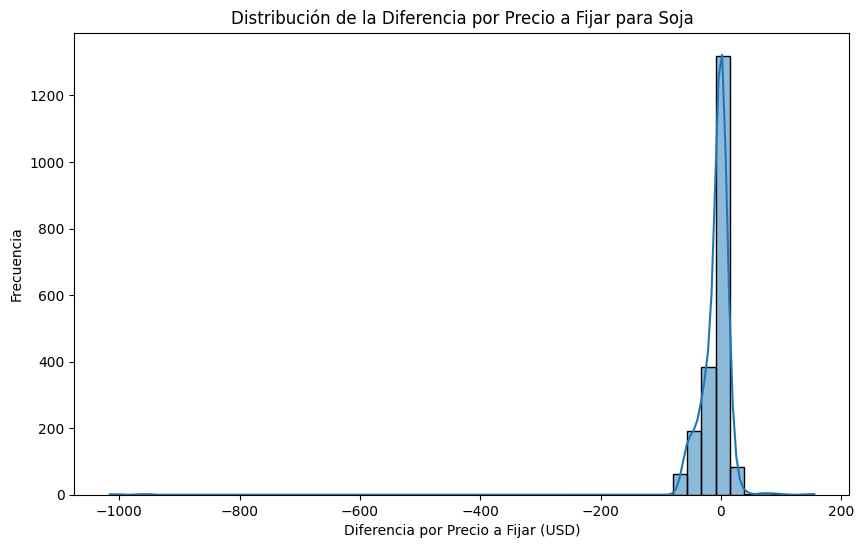

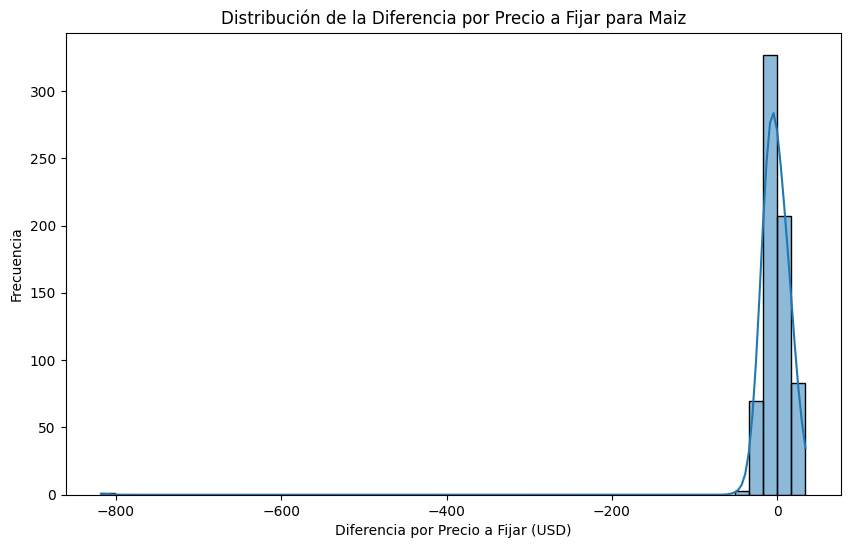

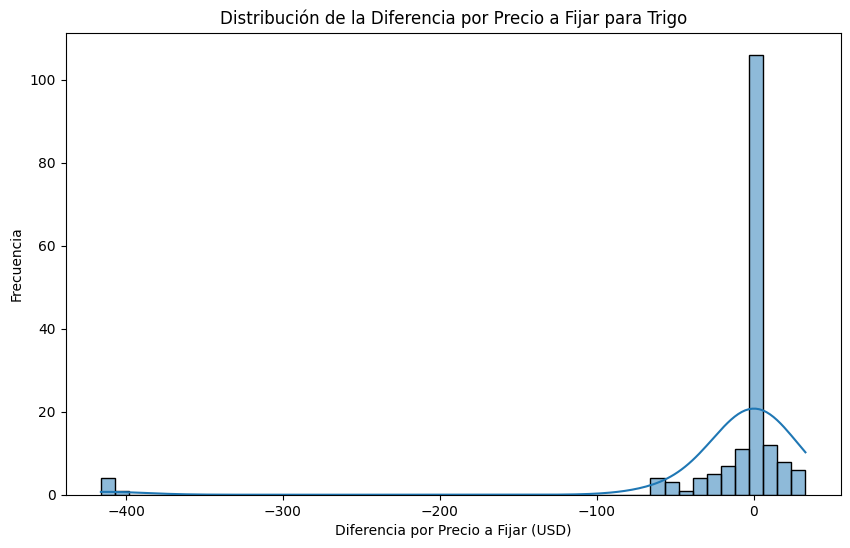

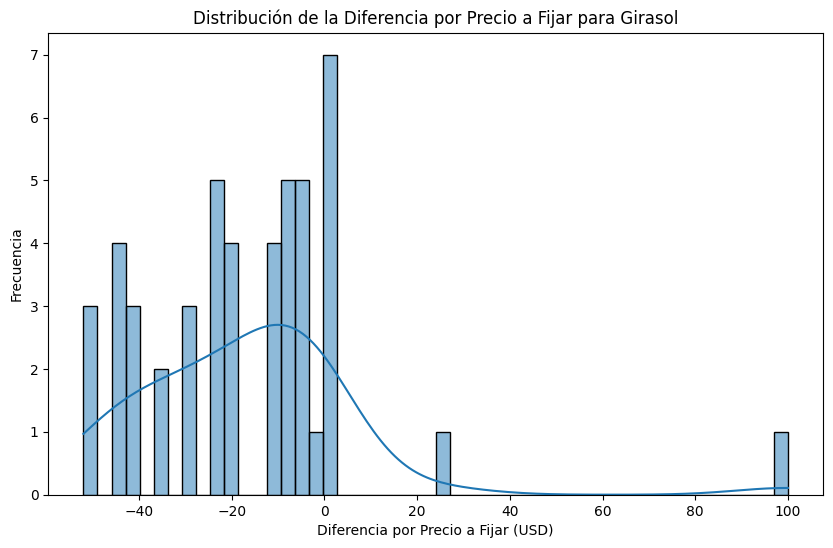

In [126]:
for grano in ['Soja', 'Maiz', 'Trigo','Girasol']:
    plt.figure(figsize=(10,6))
    sns.histplot(data=df_nonan[(df_nonan['tipoOiv_v2'] == 'Precio a Fijar') & (df_nonan['grano'] == grano)],
                 x='Ganancia USD/tn por contrato de precio a fijar', bins=50, kde=True)
    plt.title(f'Distribución de la Diferencia por Precio a Fijar para {grano}')
    plt.xlabel('Diferencia por Precio a Fijar (USD)')
    plt.ylabel('Frecuencia')
    plt.show()